In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Wine dataset

wine = load_wine()

print("Wine dataset loaded successfully!")

Wine dataset loaded successfully!


In [3]:
# Creating a Pandas DataFrame

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [5]:
# Displaying statistical summary

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
# Checking for missing values

df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [7]:
# Displaying dataset dimensions

print("Number of Rows    :", df.shape[0])
print("Number of Features:", df.shape[1])

Number of Rows    : 178
Number of Features: 13


In [8]:
# Displaying all feature names

print("Wine Dataset Features:\n")

for i, feature in enumerate(wine.feature_names, start=1):
    print(i, ":", feature)

Wine Dataset Features:

1 : alcohol
2 : malic_acid
3 : ash
4 : alcalinity_of_ash
5 : magnesium
6 : total_phenols
7 : flavanoids
8 : nonflavanoid_phenols
9 : proanthocyanins
10 : color_intensity
11 : hue
12 : od280/od315_of_diluted_wines
13 : proline


In [9]:
# Preparing features for GMM

X = df.copy()

print("Feature Shape:", X.shape)

Feature Shape: (178, 13)


In [10]:
# Standardizing the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")

print("\nScaled Data Shape:", X_scaled.shape)

Features standardized successfully!

Scaled Data Shape: (178, 13)


In [11]:
# Creating the Gaussian Mixture Model

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

print("GMM model created successfully!")

GMM model created successfully!


In [12]:
# Fitting the GMM model on the scaled features

gmm.fit(X_scaled)

print("GMM model fitted successfully!")

GMM model fitted successfully!


In [13]:
# Predicting cluster labels

cluster_labels = gmm.predict(X_scaled)

print("Cluster labels generated successfully!")

Cluster labels generated successfully!


In [14]:
# Displaying the first 20 cluster assignments

print("First 20 Cluster Labels:")

print(cluster_labels[:20])

First 20 Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [15]:
# Counting observations in each cluster

cluster_counts = pd.Series(
    cluster_labels
).value_counts().sort_index()

print("Cluster Distribution:")

display(
    cluster_counts.to_frame(
        name="Number of Samples"
    )
)

Cluster Distribution:


,Number of Samples
0,65
1,51
2,62


In [16]:
# Calculating the probability of each sample belonging to each cluster

cluster_probabilities = gmm.predict_proba(X_scaled)

print("Cluster probability shape:")
print(cluster_probabilities.shape)

Cluster probability shape:
(178, 3)


In [17]:
# Displaying cluster probabilities

probability_df = pd.DataFrame(
    cluster_probabilities,
    columns=[
        "Cluster_0_Probability",
        "Cluster_1_Probability",
        "Cluster_2_Probability"
    ]
)

display(probability_df.head(10))

,Cluster_0_Probability,Cluster_1_Probability,Cluster_2_Probability
0,1.367885e-13,4.079772e-51,1.000000
1,1.809552e-09,2.129703e-45,1.000000
2,1.778196e-09,4.311847e-56,1.000000
3,1.832492e-22,2.351804e-87,1.000000
4,3.940067e-04,1.246719e-23,0.999606
5,4.375513e-19,1.048176e-80,1.000000
6,2.615264e-17,1.986889e-54,1.000000
7,8.844574e-15,1.009189e-50,1.000000
8,1.065940e-10,4.968612e-46,1.000000
9,1.520270e-11,1.216585e-50,1.000000


In [18]:
# Calculating Akaike Information Criterion (AIC)

aic_score = gmm.aic(X_scaled)

print("AIC Score:", aic_score)

AIC Score: 4843.250256926956


In [19]:
# Calculating Bayesian Information Criterion (BIC)

bic_score = gmm.bic(X_scaled)

print("BIC Score:", bic_score)

BIC Score: 5842.330291718671


In [20]:
# Displaying AIC and BIC scores

model_scores = pd.DataFrame({
    "Metric": ["AIC", "BIC"],
    "Score": [aic_score, bic_score]
})

display(model_scores)

,Metric,Score
0,AIC,4843.250257
1,BIC,5842.330292


In [21]:
# Testing different numbers of Gaussian components

n_components_range = range(1, 8)

aic_scores = []
bic_scores = []

for n in n_components_range:
    model = GaussianMixture(
        n_components=n,
        random_state=42
    )

    model.fit(X_scaled)

    aic_scores.append(model.aic(X_scaled))
    bic_scores.append(model.bic(X_scaled))

print("AIC Scores:")
print(aic_scores)

print("\nBIC Scores:")
print(bic_scores)


AIC Scores:
[np.float64(5410.396411885755), np.float64(4964.580626982184), np.float64(4843.250256926956), np.float64(4473.65296618721), np.float64(4795.747409828102), np.float64(4862.212550990966), np.float64(4582.118042570475)]

BIC Scores:
[np.float64(5741.301901116131), np.float64(5629.57338899323), np.float64(5842.330291718671), np.float64(5806.820273759594), np.float64(6463.001990181154), np.float64(6863.554404124687), np.float64(6917.547168484866)]


In [22]:
# Creating a DataFrame for AIC and BIC comparison

model_comparison = pd.DataFrame({
    "Number of Components": list(n_components_range),
    "AIC": aic_scores,
    "BIC": bic_scores
})

display(model_comparison)

,Number of Components,AIC,BIC
0,1,5410.396412,5741.301901
1,2,4964.580627,5629.573389
2,3,4843.250257,5842.330292
3,4,4473.652966,5806.820274
4,5,4795.747410,6463.001990
5,6,4862.212551,6863.554404
6,7,4582.118043,6917.547168


In [23]:
# Finding the number of components with the lowest AIC

best_aic_components = list(
    n_components_range
)[np.argmin(aic_scores)]

best_aic = min(aic_scores)

print("Best Components according to AIC:",
      best_aic_components)

print("Lowest AIC:",
      best_aic)

Best Components according to AIC: 4
Lowest AIC: 4473.65296618721


In [24]:
# Finding the number of components with the lowest BIC

best_bic_components = list(
    n_components_range
)[np.argmin(bic_scores)]

best_bic = min(bic_scores)

print("Best Components according to BIC:",
      best_bic_components)

print("Lowest BIC:",
      best_bic)

Best Components according to BIC: 2
Lowest BIC: 5629.57338899323


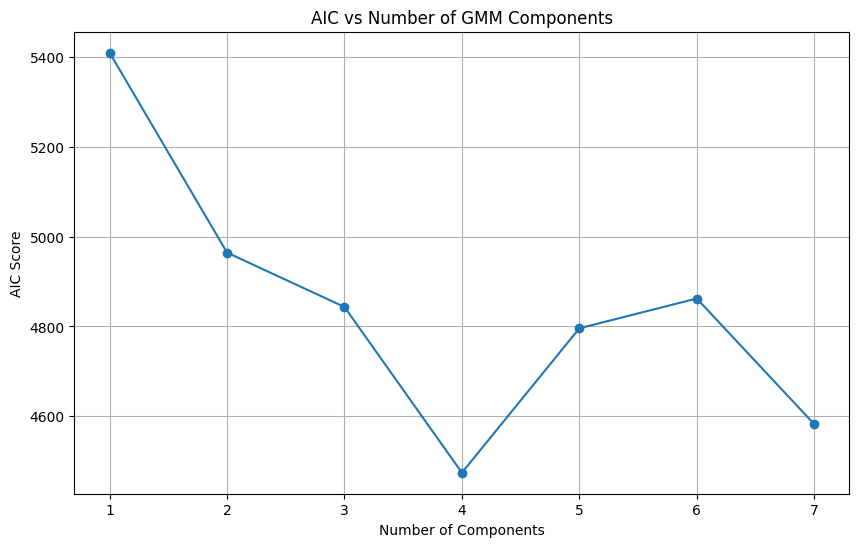

In [25]:
# Visualizing AIC scores

plt.figure(figsize=(10, 6))

plt.plot(
    list(n_components_range),
    aic_scores,
    marker="o"
)

plt.title("AIC vs Number of GMM Components")
plt.xlabel("Number of Components")
plt.ylabel("AIC Score")

plt.xticks(list(n_components_range))
plt.grid()

plt.show()

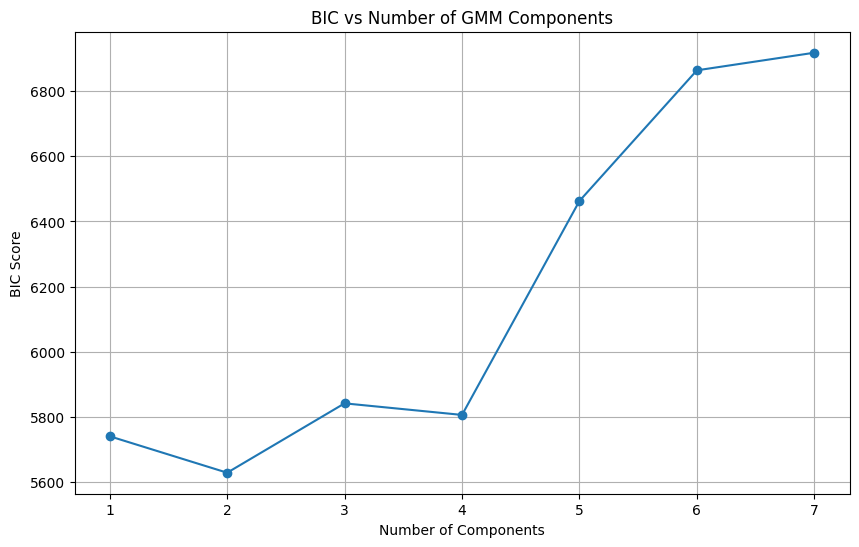

In [26]:
# Visualizing BIC scores

plt.figure(figsize=(10, 6))

plt.plot(
    list(n_components_range),
    bic_scores,
    marker="o"
)

plt.title("BIC vs Number of GMM Components")
plt.xlabel("Number of Components")
plt.ylabel("BIC Score")

plt.xticks(list(n_components_range))
plt.grid()

plt.show()

In [27]:
# Selecting the final number of GMM components

final_components = best_bic_components

print("Selected Number of Components:",
      final_components)

Selected Number of Components: 2


In [28]:
# Creating and training the final GMM model

final_gmm = GaussianMixture(
    n_components=final_components,
    random_state=42
)

final_gmm.fit(X_scaled)

print("Final GMM model trained successfully!")

Final GMM model trained successfully!


In [29]:
# Predicting final cluster assignments

final_labels = final_gmm.predict(X_scaled)

print("Final cluster labels generated successfully!")

print("\nFirst 20 Cluster Labels:")
print(final_labels[:20])

Final cluster labels generated successfully!

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
# Displaying the final cluster distribution

final_cluster_counts = (
    pd.Series(final_labels)
    .value_counts()
    .sort_index()
)

print("Final Cluster Distribution:")

display(
    final_cluster_counts.to_frame(
        name="Number of Samples"
    )
)

Final Cluster Distribution:


,Number of Samples
0,122
1,56


In [31]:
# Calculating probabilities for the final GMM clusters

final_probabilities = final_gmm.predict_proba(X_scaled)

print("Probability Shape:", final_probabilities.shape)

display(
    pd.DataFrame(
        final_probabilities,
        columns=[
            f"Cluster_{i}_Probability"
            for i in range(final_components)
        ]
    ).head(10)
)

Probability Shape: (178, 2)


,Cluster_0_Probability,Cluster_1_Probability
0,1.0,2.639315e-43
1,1.0,4.787913e-36
2,1.0,6.055181e-46
3,1.0,2.013129e-67
4,1.0,1.245628e-17
5,1.0,2.967578e-56
6,1.0,2.541084e-44
7,1.0,6.448741e-38
8,1.0,2.327897e-35
9,1.0,5.822626e-43


In [32]:
# Finding the highest cluster probability for each observation

max_probability = final_probabilities.max(axis=1)

print("Maximum cluster probabilities:")

display(
    pd.DataFrame({
        "Max_Cluster_Probability": max_probability
    }).head(10)
)

Maximum cluster probabilities:


,Max_Cluster_Probability
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
5,1.0
6,1.0
7,1.0
8,1.0
9,1.0


In [33]:
# Identifying observations with low clustering confidence

uncertainty_threshold = 0.60

uncertain_mask = (
    max_probability < uncertainty_threshold
)

uncertain_samples = np.where(
    uncertain_mask
)[0]

print(
    "Number of uncertain observations:",
    len(uncertain_samples)
)

print("\nUncertain observation indices:")
print(uncertain_samples)

Number of uncertain observations: 0

Uncertain observation indices:
[]


In [34]:
# Creating a DataFrame containing the original features
# and the final GMM cluster assignment

gmm_df = df.copy()

gmm_df["GMM_Cluster"] = final_labels
gmm_df["Cluster_Probability"] = max_probability

display(gmm_df.head(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,GMM_Cluster,Cluster_Probability
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,1.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,1.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,1.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,1.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,1.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,1.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,1.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,1.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,1.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,1.0


In [35]:
# Reducing the standardized features to 2 dimensions for visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Visualization Shape:", X_pca.shape)

PCA Visualization Shape: (178, 2)


In [36]:
# Creating a DataFrame for visualization

visualization_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "GMM_Cluster": final_labels
})

display(visualization_df.head())

,PC1,PC2,GMM_Cluster
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


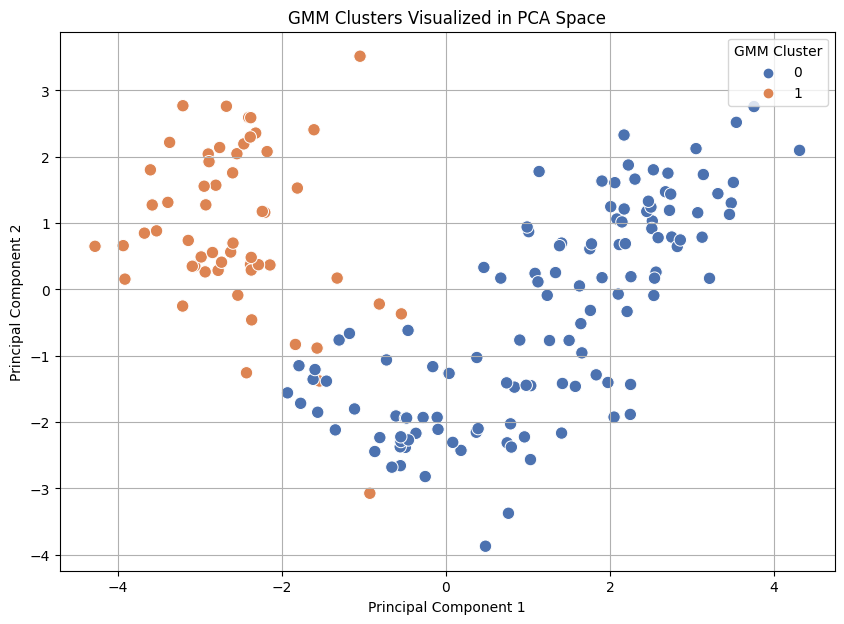

In [37]:
# Visualizing the GMM clusters

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=visualization_df,
    x="PC1",
    y="PC2",
    hue="GMM_Cluster",
    palette="deep",
    s=80
)

plt.title("GMM Clusters Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid()
plt.legend(title="GMM Cluster")

plt.show()

In [38]:
# Comparing GMM clusters with the original wine classes

comparison_df = pd.DataFrame({
    "Actual_Wine_Class": wine.target,
    "GMM_Cluster": final_labels
})

display(
    pd.crosstab(
        comparison_df["Actual_Wine_Class"],
        comparison_df["GMM_Cluster"]
    )
)

GMM_Cluster,0,1
Actual_Wine_Class,,
0,59,0
1,63,8
2,0,48


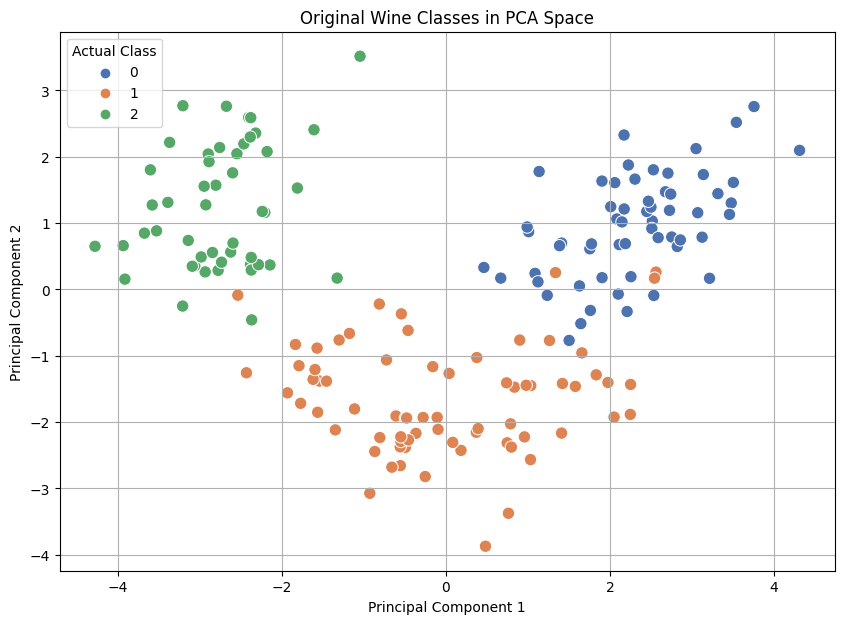

In [39]:
# Visualizing the original wine classes in PCA space

visualization_df["Actual_Class"] = wine.target

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=visualization_df,
    x="PC1",
    y="PC2",
    hue="Actual_Class",
    palette="deep",
    s=80
)

plt.title("Original Wine Classes in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid()
plt.legend(title="Actual Class")

plt.show()

In [40]:
# Evaluating the separation of GMM clusters

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    final_labels
)

print("GMM Silhouette Score:", silhouette)

GMM Silhouette Score: 0.2682319543159216
